# 2. Multi-Layer Perceptrons (MLP)

## Saving the generated models for visualization

In [1]:
!pip install onnx

In [2]:
# After training, save the model as ONNX

def save_model(model, name):
    import torch.onnx

    # Create a dummy input that matches the model's input size
    dummy_input = torch.randn(1, 2, dtype=torch.float32)

    # Specify the path for the ONNX file
    onnx_file_path = f"/content/{name}.onnx"

    # Export the model
    torch.onnx.export(model,               # model being run
                      dummy_input,         # model input (or a tuple for multiple inputs)
                      onnx_file_path,      # where to save the model (can be a file or file-like object)
                      export_params=True,  # store the trained parameter weights inside the model file
                      opset_version=10,    # the ONNX version to export the model to
                      do_constant_folding=True,  # whether to execute constant folding for optimization
                      input_names = ['input'],   # the model's input names
                      output_names = ['output'], # the model's output names
                      dynamic_axes={'input': {0: 'batch_size'},    # variable length axes
                                    'output': {0: 'batch_size'}})

    print(f"Model has been saved to {onnx_file_path}")

### Architecture Details

#### Network Architecture:

1. **Input Layer**: This layer consists of 2 neurons, corresponding to the 2 features of the input data. This layer directly receives the input data for processing by the network.

2. **Hidden Layer**: The number of neurons in the hidden layer can vary based on the experiment (3 neurons for a smaller network or 10 for a larger one). Each neuron in the hidden layer is fully connected to all neurons in the input layer.

3. **Output Layer**: This layer consists of a single neuron that outputs the prediction of the network. This neuron is fully connected to all neurons in the hidden layer.

#### Weights and Biases:

- **Weights**: Each connection between neurons in consecutive layers has an associated weight. Using PyTorch, these weights are initialized randomly by default. For connections between the input layer and the hidden layer (`self.hidden` in the `MLP` class), and between the hidden layer and the output layer (`self.output`), weights are initialized using the default initialization strategy.
  
- **Biases**: Each neuron in the hidden and output layers has an associated bias. In PyTorch, biases are also initialized randomly by default.

#### Activation Functions:

- **Hidden Layer Activation**: The tanh (hyperbolic tangent) activation function has been used for neurons in the hidden layer.

- **Output Layer Activation**: The sigmoid activation function is used for the neuron in the output layer. Sigmoid is a non-linear activation function that outputs values in the range [0, 1], making it suitable for binary classification tasks. The output can be interpreted as the probability of the input data belonging to one of the classes.

#### Training:

- **Loss Function**: Binary Cross-Entropy Loss (BCELoss) is used as the loss function.

- **Optimizer**: Stochastic Gradient Descent (SGD) with a learning rate of 0.01 is used to minimize the loss function.

- **Backpropagation**: During training, backpropagation calculates the gradients of the loss function with respect to each weight and bias in the network. These gradients are used by the optimizer to update the weights and biases, gradually improving the model's predictions.

Model has been saved to /content/model3.onnx


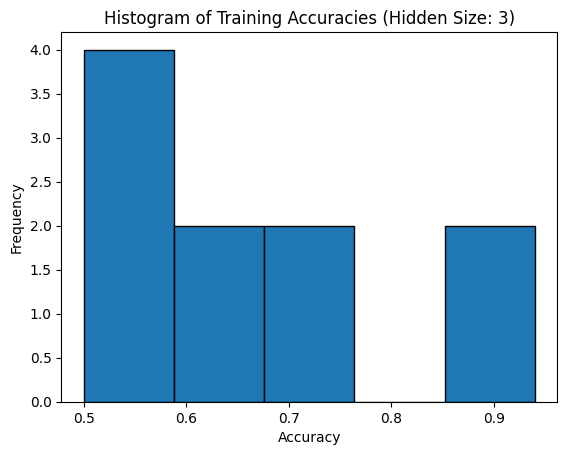

Accuracy scores for 3 hidden neurons:
Accuracy for Iteration 1 : 0.6475
Accuracy for Iteration 2 : 0.5025
Accuracy for Iteration 3 : 0.7225
Accuracy for Iteration 4 : 0.73
Accuracy for Iteration 5 : 0.655
Accuracy for Iteration 6 : 0.885
Accuracy for Iteration 7 : 0.5
Accuracy for Iteration 8 : 0.5025
Accuracy for Iteration 9 : 0.5
Accuracy for Iteration 10 : 0.94



Model has been saved to /content/model10.onnx


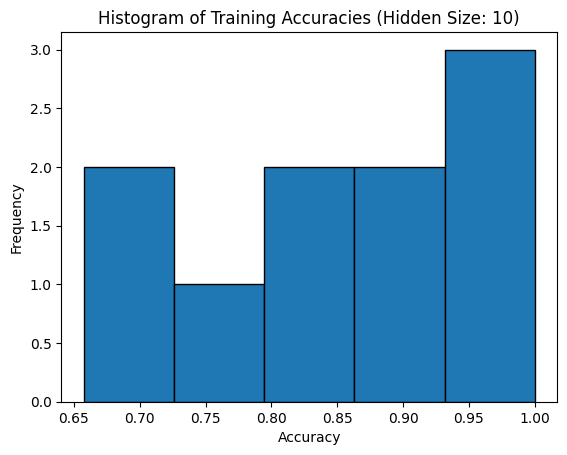

Accuracy scores for 10 hidden neurons:
Accuracy for Iteration 1 : 0.805
Accuracy for Iteration 2 : 0.925
Accuracy for Iteration 3 : 0.9975
Accuracy for Iteration 4 : 0.6575
Accuracy for Iteration 5 : 0.975
Accuracy for Iteration 6 : 0.8525
Accuracy for Iteration 7 : 1.0
Accuracy for Iteration 8 : 0.915
Accuracy for Iteration 9 : 0.79
Accuracy for Iteration 10 : 0.665





In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load the dataset
data = np.load('hw1_p2.npy')
X = torch.tensor(data[:, :2], dtype=torch.float32)
y = torch.tensor(data[:, 2], dtype=torch.float32)

# Define the MLP model
class MLP(nn.Module):
    def __init__(self, hidden_size):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(2, hidden_size)  # 2 inputs to hidden neurons
        self.output = nn.Linear(hidden_size, 1)  # hidden neurons to 1 output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

# Function to train the model
def train_model(model, X, y):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    epochs = 1000
    for _ in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs.squeeze(), y)
        loss.backward()
        optimizer.step()
    return model


hidden_sizes = [3, 10]
for hidden_size in hidden_sizes:
    accuracies = []
    for _ in range(10):
        model = MLP(hidden_size=hidden_size)
        trained_model = train_model(model, X, y)
        predictions = trained_model(X).squeeze().detach().numpy()
        predicted_classes = predictions.round()
        accuracy = accuracy_score(y.numpy(), predicted_classes)
        accuracies.append(accuracy)

    save_model(trained_model, "model" + str(hidden_size))

    # Plot histogram of accuracies for the current hidden layer size
    plt.hist(accuracies, bins=5, edgecolor='black')
    plt.xlabel('Accuracy')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Training Accuracies (Hidden Size: {hidden_size})')
    plt.show()

    print("Accuracy scores for",hidden_size,"hidden neurons:")
    for i in range(len(accuracies)):
        print("Accuracy for Iteration",i+1,":",accuracies[i])
    print("\n\n")

Based on the accuracy scores, we can say that the model is able to find a solution in each run. However, the accuracy improves by increasing the number of hidden neurons as this allows us to fit to the non-linear properties of the data better.

## Visualizing the Network Architecture

In [4]:
!pip install -q netron

To inspect the details of a specific layer, node, or edge, simply click on it. A sidebar will appear, displaying properties such as layer type, dimensions, activation functions, as well as the learned weights and biases.



In [5]:
import netron
import portpicker
from google.colab import output

port = portpicker.pick_unused_port()

# Read the model file and start the netron browser.
with output.temporary():
  netron.start('model3.onnx', port, browse=False)

output.serve_kernel_port_as_iframe(port, height='800', width='800')

<IPython.core.display.Javascript object>

In [6]:
with output.temporary():
  netron.start('model10.onnx', port, browse=False)

output.serve_kernel_port_as_iframe(port, height='800', width='800')

<IPython.core.display.Javascript object>